#Customer Chrun Prediction
In this project, a machine learning model will be developed to predict whether customers will churn (cancel their subscription) or not.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train_path = "../data/customer_churn_dataset-training-master.csv"
test_path = "../data/customer_churn_dataset-testing-master.csv"

In [4]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

In [5]:
train_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [6]:
print(train_df.shape)

(440833, 12)


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [8]:
train_df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [9]:
train_df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [10]:
train_df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [11]:
train_df["Churn"].value_counts()

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

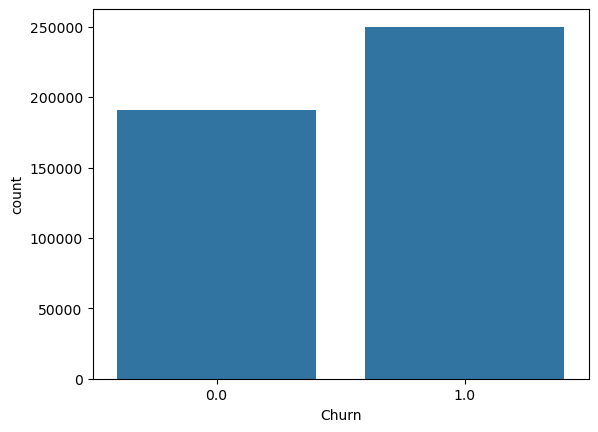

In [12]:
sns.countplot(x="Churn", data=train_df)

In [13]:
train_df[train_df.isnull().any(axis=1)]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
train_df=train_df.dropna()

In [15]:
train_df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [16]:
train_df.shape


(440832, 12)

In [17]:
X = train_df.drop("Churn", axis=1)
y = train_df["Churn"]

In [18]:
X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

In [19]:
X = pd.get_dummies(X, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

In [20]:
X.shape

(440832, 13)

In [21]:
X_test.shape

(64374, 13)

In [22]:
X.head()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,2.0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,False,False,True,False,False
1,3.0,65.0,49.0,1.0,10.0,8.0,557.0,6.0,False,False,False,True,False
2,4.0,55.0,14.0,4.0,6.0,18.0,185.0,3.0,False,False,False,False,True
3,5.0,58.0,38.0,21.0,7.0,7.0,396.0,29.0,True,False,True,True,False
4,6.0,23.0,32.0,20.0,5.0,8.0,617.0,20.0,True,False,False,True,False


In [23]:
X = X.astype(int)
X_test = X_test.astype(int)

In [24]:
X.head()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,2,30,39,14,5,18,932,17,0,0,1,0,0
1,3,65,49,1,10,8,557,6,0,0,0,1,0
2,4,55,14,4,6,18,185,3,0,0,0,0,1
3,5,58,38,21,7,7,396,29,1,0,1,1,0
4,6,23,32,20,5,8,617,20,1,0,0,1,0


In [25]:
!pip install scikit-learn

In [26]:
import sys
!{sys.executable} -m pip install scikit-learn

In [27]:
from sklearn.preprocessing import StandardScaler

In [63]:
scaler=StandardScaler()

In [65]:
X=scaler.fit_transform(X)

In [67]:
X_test = scaler.transform(X_test)

In [83]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [85]:
y_pred = model.predict(X_test)

In [87]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [89]:
print("Accuracy", accuracy_score(y_test, y_pred))


Accuracy 0.47368502811694163


In [91]:
print(confusion_matrix(y_test,y_pred))

[[    0 33881]
 [    0 30493]]


In [93]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     33881
           1       0.47      1.00      0.64     30493

    accuracy                           0.47     64374
   macro avg       0.24      0.50      0.32     64374
weighted avg       0.22      0.47      0.30     64374



C:\Users\abbdu\anaconda3\envs\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\abbdu\anaconda3\envs\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\abbdu\anaconda3\envs\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [105]:
model2= LogisticRegression(class_weight="balanced", max_iter=1000)
model2.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [107]:
y_pred2 = model2.predict(X_test)

In [109]:
print("Accuracy:", accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

Accuracy: 0.47368502811694163
[[    0 33881]
 [    0 30493]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     33881
           1       0.47      1.00      0.64     30493

    accuracy                           0.47     64374
   macro avg       0.24      0.50      0.32     64374
weighted avg       0.22      0.47      0.30     64374



C:\Users\abbdu\anaconda3\envs\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\abbdu\anaconda3\envs\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\abbdu\anaconda3\envs\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [111]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X, y)

y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[    0 33881]
 [    0 30493]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     33881
           1       0.47      1.00      0.64     30493

    accuracy                           0.47     64374
   macro avg       0.24      0.50      0.32     64374
weighted avg       0.22      0.47      0.30     64374



C:\Users\abbdu\anaconda3\envs\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\abbdu\anaconda3\envs\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\abbdu\anaconda3\envs\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [113]:
print("Train target distribution:")
print(y.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

print("Train target ratio:")
print(y.value_counts(normalize=True))

print("\nTest target ratio:")
print(y_test.value_counts(normalize=True))

Train target distribution:
Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

Test target distribution:
Churn
0    33881
1    30493
Name: count, dtype: int64
Train target ratio:
Churn
1.0    0.567107
0.0    0.432893
Name: proportion, dtype: float64

Test target ratio:
Churn
0    0.526315
1    0.473685
Name: proportion, dtype: float64


In [115]:
import numpy as np

print("Logistic unique predictions:", np.unique(y_pred2, return_counts=True))
print("RandomForest unique predictions:", np.unique(y_pred_rf, return_counts=True))

Logistic unique predictions: (array([1.]), array([64374], dtype=int64))
RandomForest unique predictions: (array([1.]), array([64374], dtype=int64))


In [117]:
y_pred_train_lr = model2.predict(X)

print(confusion_matrix(y, y_pred_train_lr))
print(classification_report(y, y_pred_train_lr, zero_division=0))

[[187453   3380]
 [  6001 243998]]
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98    190833
         1.0       0.99      0.98      0.98    249999

    accuracy                           0.98    440832
   macro avg       0.98      0.98      0.98    440832
weighted avg       0.98      0.98      0.98    440832



In [119]:
y_pred_train_rf = rf.predict(X)

print(confusion_matrix(y, y_pred_train_rf))
print(classification_report(y, y_pred_train_rf, zero_division=0))

[[190833      0]
 [     0 249999]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    190833
         1.0       1.00      1.00      1.00    249999

    accuracy                           1.00    440832
   macro avg       1.00      1.00      1.00    440832
weighted avg       1.00      1.00      1.00    440832



In [121]:
train_processed = pd.DataFrame(X)
test_processed = pd.DataFrame(X_test)

print(train_processed.mean().head(10))
print(test_processed.mean().head(10))

0   -1.237879e-17
1    1.547349e-18
2    1.418403e-17
3   -1.727873e-17
4    4.951517e-17
5   -3.094698e-18
6    2.269445e-17
7   -4.229421e-17
8   -5.673614e-17
9   -8.204174e-17
dtype: float64
0   -1.740115
1   -3.147665
2   -1.808882
3   -1.850893
4   -0.983442
5   -1.508948
6   -2.624267
7   -1.670790
8   -1.558787
9   -0.733544
dtype: float64


In [140]:
#Create own data splits


In [123]:
df = pd.concat([train_df, test_df], axis=0)

In [125]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X = pd.get_dummies(X, drop_first=True)
X = X.astype(int)

In [127]:
from sklearn.model_selection import train_test_split

X_train, X_test_new, y_train, y_test_new = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [129]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test_new = scaler.transform(X_test_new)

In [131]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test_new)

In [134]:
print(confusion_matrix(y_test_new, y_pred))
print(classification_report(y_test_new, y_pred))

[[38124  6857]
 [ 4952 51109]]
              precision    recall  f1-score   support

         0.0       0.89      0.85      0.87     44981
         1.0       0.88      0.91      0.90     56061

    accuracy                           0.88    101042
   macro avg       0.88      0.88      0.88    101042
weighted avg       0.88      0.88      0.88    101042



In [136]:
coefficients = model.coef_[0]

feature_names = X.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": coefficients
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
4,Support Calls,0.912581
11,Contract Length_Monthly,0.571359
5,Payment Delay,0.569111
1,Age,0.224568
7,Last Interaction,0.200181
2,Tenure,0.012926
12,Contract Length_Quarterly,-0.002858
10,Subscription Type_Standard,-0.029540
9,Subscription Type_Premium,-0.032398
3,Usage Frequency,-0.094866


In [138]:
from sklearn.metrics import roc_auc_score

y_proba = model.predict_proba(X_test_new)[:,1]

roc_auc_score(y_test_new, y_proba)

0.9154083962080577

In [142]:
#One More Model (XGBoost)

In [149]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [150]:
from xgboost import XGBClassifier

In [185]:
X_model = df.drop(["Churn", "CustomerID"], axis=1)
y_model = df["Churn"]

X_model = pd.get_dummies(X_model, drop_first=True)
X_model = X_model.astype(int)

feature_names = X_model.columns

X_train, X_test_new, y_train, y_test_new = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42
)

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test_new)

print("Accuracy:", accuracy_score(y_test_new, y_pred_xgb))
print(confusion_matrix(y_test_new, y_pred_xgb))
print(classification_report(y_test_new, y_pred_xgb))

importances = xgb.feature_importances_

print("Feature count:", len(feature_names))
print("Importance count:", len(importances))

feat_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feat_importance.head(10)

Accuracy: 0.9320579560974644
[[38489  6492]
 [  373 55688]]
              precision    recall  f1-score   support

         0.0       0.99      0.86      0.92     44981
         1.0       0.90      0.99      0.94     56061

    accuracy                           0.93    101042
   macro avg       0.94      0.92      0.93    101042
weighted avg       0.94      0.93      0.93    101042

Feature count: 12
Importance count: 12


,Feature,Importance
3,Support Calls,0.367326
10,Contract Length_Monthly,0.218966
5,Total Spend,0.149153
4,Payment Delay,0.086949
0,Age,0.061372
6,Last Interaction,0.043677
7,Gender_Male,0.040710
1,Tenure,0.011901
8,Subscription Type_Premium,0.008316
2,Usage Frequency,0.005035
